In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [36]:
# Load listing-level summary
df = pd.read_csv("listing_mismatch_summary.csv")
df["abs_proxy_mean"] = df["proxy_mean"].abs()
df["log_review_count"] = np.log1p(df["review_count"])

df.head()

,listing_id,proxy_mean,proxy_std,review_count,mabs_mean,mover_mean,munder_mean,rating_mean,delta_S01,delta_S02,...,delta_S05,delta_S06,delta_S07,delta_S08,delta_S09,delta_S10,over_ratio,under_ratio,abs_proxy_mean,log_review_count
0,2992450,-0.019241,0.037255,7,0.110372,0.029528,0.080843,3.56,-0.129590,-0.017121,...,-0.030846,-0.044808,-0.119347,-0.047849,-0.022136,-0.062892,0.428571,0.571429,0.019241,2.079442
1,3820211,0.001695,0.037708,217,0.108555,0.051725,0.056829,4.75,-0.092216,0.053902,...,-0.019371,-0.000775,-0.037092,-0.141102,0.008011,0.239679,0.534562,0.465438,0.001695,5.384495
2,5651579,0.016489,0.042660,175,0.090785,0.052240,0.038544,4.52,0.021029,0.069662,...,0.006016,0.060056,0.012782,-0.047897,-0.001518,-0.030558,0.611429,0.388571,0.016489,5.170484
3,6623339,0.004628,0.038142,210,0.102109,0.051447,0.050663,4.73,-0.082988,0.058349,...,-0.021749,-0.006202,-0.031976,-0.106420,0.004218,0.217072,0.523810,0.476190,0.004628,5.351858
4,9005989,0.024864,0.038229,330,0.105938,0.057110,0.048828,4.79,-0.101052,0.050667,...,-0.010059,0.206507,-0.056840,-0.085831,0.077985,-0.034689,0.745455,0.254545,0.024864,5.802118


In [37]:
# Load review-level LLM mismatch scores (listing_id, review_id, description/review scores, mismatch_proxy, mabs, mover, munder, deltas, etc.)
df_llm = pd.read_csv("../Mismatch_Score/llm_mismatch_score.csv")
df_llm.head()

,listing_id,review_id,listing_name,description,review,rating,row_idx,desc_S01_score,desc_S02_score,desc_S03_score,...,delta_S01,delta_S02,delta_S03,delta_S04,delta_S05,delta_S06,delta_S07,delta_S08,delta_S09,delta_S10
0,2992450,15066586,Luxury 2 bedroom apartment,The apartment is located in a quiet neighborho...,Large apartment; nice kitchen and bathroom. Ke...,3.56,0,0.486529,0.615041,0.471996,...,-0.027420,-0.015043,-0.231962,0.076894,-0.072865,0.029635,-0.039238,-0.166167,0.027249,-0.044143
1,2992450,21810844,Luxury 2 bedroom apartment,The apartment is located in a quiet neighborho...,"This may be a little late, but just to say Ken...",3.56,1,0.486529,0.615041,0.471996,...,-0.330063,-0.063637,-0.294175,-0.000140,-0.002681,0.037091,-0.256779,-0.339532,0.012517,0.045995
2,2992450,27434334,Luxury 2 bedroom apartment,The apartment is located in a quiet neighborho...,The apartment was very clean and convenient to...,3.56,2,0.486529,0.615041,0.471996,...,-0.042728,0.089194,0.020902,0.111244,-0.026709,0.001584,0.082508,0.033485,0.044817,-0.003964
3,2992450,28524578,Luxury 2 bedroom apartment,The apartment is located in a quiet neighborho...,Kenneth was ready when I got there and arrange...,3.56,3,0.486529,0.615041,0.471996,...,-0.110723,-0.000571,-0.094493,0.070186,-0.059033,-0.026904,-0.227332,-0.075778,-0.048920,-0.068160
4,2992450,35913434,Luxury 2 bedroom apartment,The apartment is located in a quiet neighborho...,We were pleased to see how 2nd Street and the ...,3.56,4,0.486529,0.615041,0.471996,...,-0.391927,-0.281493,-0.028824,-0.224062,-0.035123,-0.301200,-0.207145,-0.024869,-0.271738,-0.304072


In [ ]:
# Load listings (gzip). 若文件不在当前目录，请修改路径，例如 "../listings.csv.gz"
#df_listings = pd.read_csv("../listings.csv.gz", compression="gzip", low_memory=False)
#print(f"Listings: {len(df_listings)} rows, {len(df_listings.columns)} columns")
#df_listings.head()

Listings: 478 rows, 79 columns


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2992450,https://www.airbnb.com/rooms/2992450,20251107023918,2025-11-07,city scrape,Luxury 2 bedroom apartment,The apartment is located in a quiet neighborho...,NaN,https://a0.muscache.com/pictures/44627226/0e72...,4621559,...,4.56,3.22,3.67,NaN,f,1,1,0,0,0.07
1,3820211,https://www.airbnb.com/rooms/3820211,20251107023918,2025-11-07,city scrape,Restored Precinct in Center Sq. w/Parking,Step into the charming and comfy 1BR/1BA apart...,Overview<br /><br />The lovely apartment is lo...,https://a0.muscache.com/pictures/prohost-api/H...,19648678,...,4.81,4.82,4.78,NaN,f,5,5,0,0,2.30
2,5651579,https://www.airbnb.com/rooms/5651579,20251107023918,2025-11-07,city scrape,Large studio apt by Capital Center & ESP@,"Spacious studio with hardwood floors, fully eq...",The neighborhood is very eclectic. We have a v...,https://a0.muscache.com/pictures/b3fc42f3-6e5e...,29288920,...,4.88,4.77,4.64,NaN,f,2,1,1,0,2.95
3,6623339,https://www.airbnb.com/rooms/6623339,20251107023918,2025-11-07,city scrape,Center Sq. Loft in Converted Precinct w/ Parking,Step into the charming and comfy 1BR/1BA apart...,Overview<br /><br />The lovely apartment is lo...,https://a0.muscache.com/pictures/prohost-api/H...,19648678,...,4.70,4.80,4.72,NaN,f,5,5,0,0,2.62
4,9005989,https://www.airbnb.com/rooms/9005989,20251107023918,2025-11-07,city scrape,"Studio in The heart of Center SQ, in Albany NY",(21 years of age or older ONLY) NON- SMOKING.....,"There are many shops, restaurants, bars, museu...",https://a0.muscache.com/pictures/d242a77e-437c...,17766924,...,4.93,4.87,4.77,NaN,f,1,1,0,0,5.53


In [51]:
# Load listings (gzip). 若文件不在当前目录，请修改路径，例如 "../listings.csv.gz"
df_listings = pd.read_csv("../reviews.csv.gz", compression="gzip", low_memory=False)
print(f"Listings: {len(df_listings)} rows, {len(df_listings.columns)} columns")
df_listings.columns

Listings: 28387 rows, 6 columns


Index(['listing_id', 'id', 'date', 'reviewer_id', 'reviewer_name', 'comments'], dtype='object')

In [52]:
df_listings.head()

,listing_id,id,date,reviewer_id,reviewer_name,comments
0,2992450,15066586,2014-07-01,16827297,Kristen,Large apartment; nice kitchen and bathroom. Ke...
1,2992450,21810844,2014-10-24,22648856,Christopher,"This may be a little late, but just to say Ken..."
2,2992450,27434334,2015-03-04,45406,Altay,The apartment was very clean and convenient to...
3,2992450,28524578,2015-03-25,5485362,John,Kenneth was ready when I got there and arrange...
4,2992450,35913434,2015-06-23,15772025,Jennifer,We were pleased to see how 2nd Street and the ...


In [ ]:
# df_listings.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_thumbnail_url', 'host_picture_url',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'ca

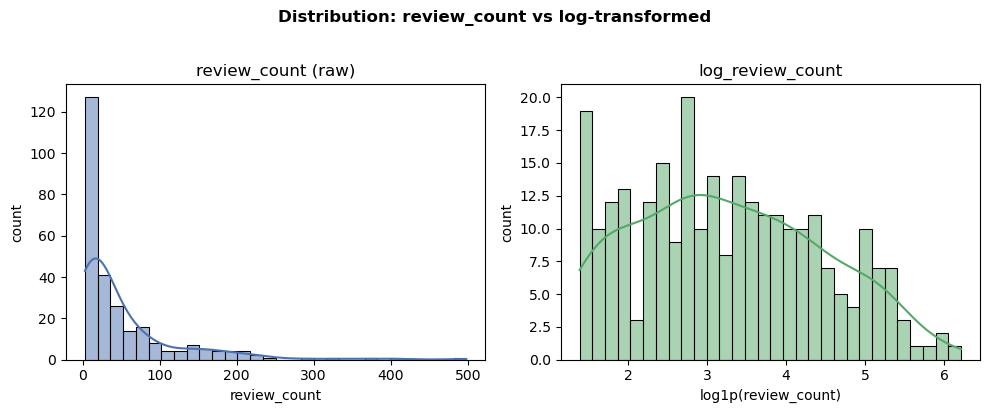

In [38]:
# review_count 与 log1p(review_count) 的分布对比
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(df["review_count"], kde=True, ax=axes[0], color="#4C72B0", bins=30)
axes[0].set_xlabel("review_count")
axes[0].set_ylabel("count")
axes[0].set_title("review_count (raw)")
sns.histplot(df["log_review_count"], kde=True, ax=axes[1], color="#55A868", bins=30)
axes[1].set_xlabel("log1p(review_count)")
axes[1].set_ylabel("count")
axes[1].set_title("log_review_count")
plt.suptitle("Distribution: review_count vs log-transformed", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 1. Relationship: reivew count & mismatch

In [5]:
# Spearman: review_count vs abs(proxy_mean), mabs_mean, proxy_mean, mover_mean, munder_mean
rho_abs, p_abs = stats.spearmanr(df["review_count"], df["abs_proxy_mean"], nan_policy="omit")
rho_mabs, p_mabs = stats.spearmanr(df["review_count"], df["mabs_mean"], nan_policy="omit")
rho_proxy, p_proxy = stats.spearmanr(df["review_count"], df["proxy_mean"], nan_policy="omit")
rho_std, p_std = stats.spearmanr(df["review_count"], df["proxy_std"], nan_policy="omit")
rho_mover, p_mover = stats.spearmanr(df["review_count"], df["mover_mean"], nan_policy="omit")
rho_munder, p_munder = stats.spearmanr(df["review_count"], df["munder_mean"], nan_policy="omit")

print(f"review_count vs abs_proxy_mean: rho={rho_abs:.4f}, p={p_abs:.4e}")
print(f"review_count vs mabs_mean:      rho={rho_mabs:.4f}, p={p_mabs:.4e}")
print(f"review_count vs proxy_mean:      rho={rho_proxy:.4f}, p={p_proxy:.4e}")
print(f"review_count vs proxy_std:       rho={rho_std:.4f}, p={p_std:.4e}")
print(f"review_count vs mover_mean:     rho={rho_mover:.4f}, p={p_mover:.4e}")
print(f"review_count vs munder_mean:    rho={rho_munder:.4f}, p={p_munder:.4e}")

review_count vs abs_proxy_mean: rho=-0.1440, p=1.7458e-02
review_count vs mabs_mean:      rho=-0.0086, p=8.8779e-01
review_count vs proxy_mean:      rho=-0.0838, p=1.6804e-01
review_count vs proxy_std:       rho=-0.0937, p=1.2320e-01
review_count vs mover_mean:     rho=-0.0509, p=4.0332e-01
review_count vs munder_mean:    rho=0.1103, p=6.9341e-02


In [6]:
# Pearson: log_review_count vs abs(proxy_mean), mabs_mean, proxy_mean, mover_mean, munder_mean
rho_abs, p_abs = stats.pearsonr(df["log_review_count"], df["abs_proxy_mean"])
rho_mabs, p_mabs = stats.pearsonr(df["log_review_count"], df["mabs_mean"])
rho_proxy, p_proxy = stats.pearsonr(df["log_review_count"], df["proxy_mean"])
rho_std, p_std = stats.pearsonr(df["log_review_count"], df["proxy_std"])
rho_mover, p_mover = stats.pearsonr(df["log_review_count"], df["mover_mean"])
rho_munder, p_munder = stats.pearsonr(df["log_review_count"], df["munder_mean"])

print(f"log review_count vs abs_proxy_mean: rho={rho_abs:.4f}, p={p_abs:.4e}")
print(f"log review_count vs mabs_mean:      rho={rho_mabs:.4f}, p={p_mabs:.4e}")
print(f"log review_count vs proxy_mean:      rho={rho_proxy:.4f}, p={p_proxy:.4e}")
print(f"log review_count vs proxy_std:       rho={rho_std:.4f}, p={p_std:.4e}")
print(f"log review_count vs mover_mean:     rho={rho_mover:.4f}, p={p_mover:.4e}")
print(f"log review_count vs munder_mean:    rho={rho_munder:.4f}, p={p_munder:.4e}")

log review_count vs abs_proxy_mean: rho=-0.1315, p=3.0136e-02
log review_count vs mabs_mean:      rho=-0.0830, p=1.7252e-01
log review_count vs proxy_mean:      rho=-0.0402, p=5.0939e-01
log review_count vs proxy_std:       rho=-0.1684, p=5.3657e-03
log review_count vs mover_mean:     rho=-0.1407, p=2.0233e-02
log review_count vs munder_mean:    rho=0.0532, p=3.8200e-01


- 根绝pearson,log review count与abs_proxy, mover_mean，proxy_std存在显著线性负相关关系

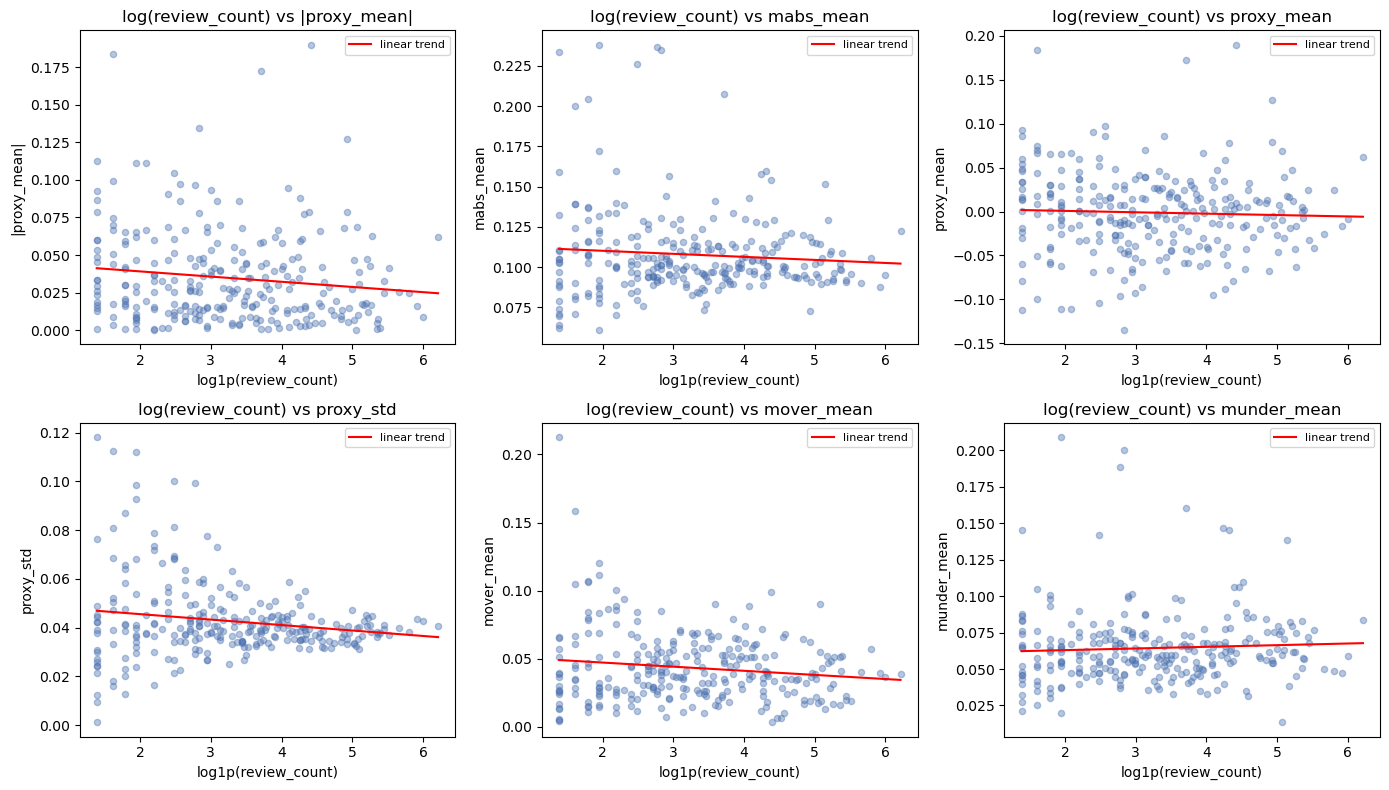

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
cols = ["abs_proxy_mean", "mabs_mean", "proxy_mean", "proxy_std", "mover_mean", "munder_mean"]
ylabels = ["|proxy_mean|", "mabs_mean", "proxy_mean", "proxy_std", "mover_mean", "munder_mean"]
for ax, col, ylabel in zip(axes.ravel(), cols, ylabels):
    ax.scatter(df["log_review_count"], df[col], alpha=0.4, s=20, color="#4C72B0")
    z = np.polyfit(df["log_review_count"], df[col], 1)
    x_plot = df["log_review_count"].sort_values()
    ax.plot(x_plot, np.poly1d(z)(x_plot), "r-", lw=1.5, label="linear trend")
    ax.set_xlabel("log1p(review_count)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"log(review_count) vs {ylabel}")
    ax.legend(fontsize=8)
plt.tight_layout()
#plt.savefig("review_count_vs_mismatch.png", dpi=150, bbox_inches="tight")

**简要结论**：评论数越多, 其 mismatch幅度（abs_proxy）倾向于更小, 且更稳定（std小），说明desc和rev普遍更align, 且"oversells"更少

## 2. Relationship: rating & mismatch

In [7]:
# Spearman: rating (raw 与 log 的 Spearman 相同，用 raw 报告即可)
rho_abs, p_abs = stats.spearmanr(df["rating_mean"], df["abs_proxy_mean"])
rho_mabs, p_mabs = stats.spearmanr(df["rating_mean"], df["mabs_mean"])
rho_proxy, p_proxy = stats.spearmanr(df["rating_mean"], df["proxy_mean"])
rho_std, p_std = stats.spearmanr(df["rating_mean"], df["proxy_std"])
rho_mover, p_mover = stats.spearmanr(df["rating_mean"], df["mover_mean"])
rho_munder, p_munder = stats.spearmanr(df["rating_mean"], df["munder_mean"])

print(f"rating vs abs_proxy_mean: ρ = {rho_abs:.4f}, p = {p_abs:.4f}")
print(f"rating vs mabs_mean:     ρ = {rho_mabs:.4f}, p = {p_mabs:.4f}")
print(f"rating vs proxy_mean:    ρ = {rho_proxy:.4f}, p = {p_proxy:.4f}")
print(f"rating vs proxy_std:     ρ = {rho_std:.4f}, p = {p_std:.4f}")
print(f"rating vs mover_mean:    ρ = {rho_mover:.4f}, p = {p_mover:.4f}")
print(f"rating vs munder_mean:   ρ = {rho_munder:.4f}, p = {p_munder:.4f}")

rating vs abs_proxy_mean: ρ = -0.0302, p = 0.6202
rating vs mabs_mean:     ρ = -0.0559, p = 0.3588
rating vs proxy_mean:    ρ = -0.0496, p = 0.4149
rating vs proxy_std:     ρ = -0.2678, p = 0.0000
rating vs mover_mean:    ρ = -0.3191, p = 0.0000
rating vs munder_mean:   ρ = 0.3117, p = 0.0000


In [8]:
# Pearson:
rho_abs, p_abs = stats.pearsonr(df["rating_mean"], df["abs_proxy_mean"])
rho_mabs, p_mabs = stats.pearsonr(df["rating_mean"], df["mabs_mean"])
rho_proxy, p_proxy = stats.pearsonr(df["rating_mean"], df["proxy_mean"])
rho_std, p_std = stats.pearsonr(df["rating_mean"], df["proxy_std"])
rho_mover, p_mover = stats.pearsonr(df["rating_mean"], df["mover_mean"])
rho_munder, p_munder = stats.pearsonr(df["rating_mean"], df["munder_mean"])

print(f"log_rating vs abs_proxy_mean: ρ = {rho_abs:.4f}, p = {p_abs:.4f}")
print(f"log_rating vs mabs_mean:     ρ = {rho_mabs:.4f}, p = {p_mabs:.4f}")
print(f"log_rating vs proxy_mean:    ρ = {rho_proxy:.4f}, p = {p_proxy:.4f}")
print(f"log_rating vs proxy_std:     ρ = {rho_std:.4f}, p = {p_std:.4f}")
print(f"log_rating vs mover_mean:    ρ = {rho_mover:.4f}, p = {p_mover:.4f}")
print(f"log_rating vs munder_mean:   ρ = {rho_munder:.4f}, p = {p_munder:.4f}")

log_rating vs abs_proxy_mean: ρ = -0.0147, p = 0.8097
log_rating vs mabs_mean:     ρ = -0.1916, p = 0.0015
log_rating vs proxy_mean:    ρ = -0.0953, p = 0.1169
log_rating vs proxy_std:     ρ = -0.4022, p = 0.0000
log_rating vs mover_mean:    ρ = -0.4203, p = 0.0000
log_rating vs munder_mean:   ρ = 0.2190, p = 0.0003


- 根绝pearson,ratingt与mabs, proxy_std, mover, munder存在显著线性负相关关系

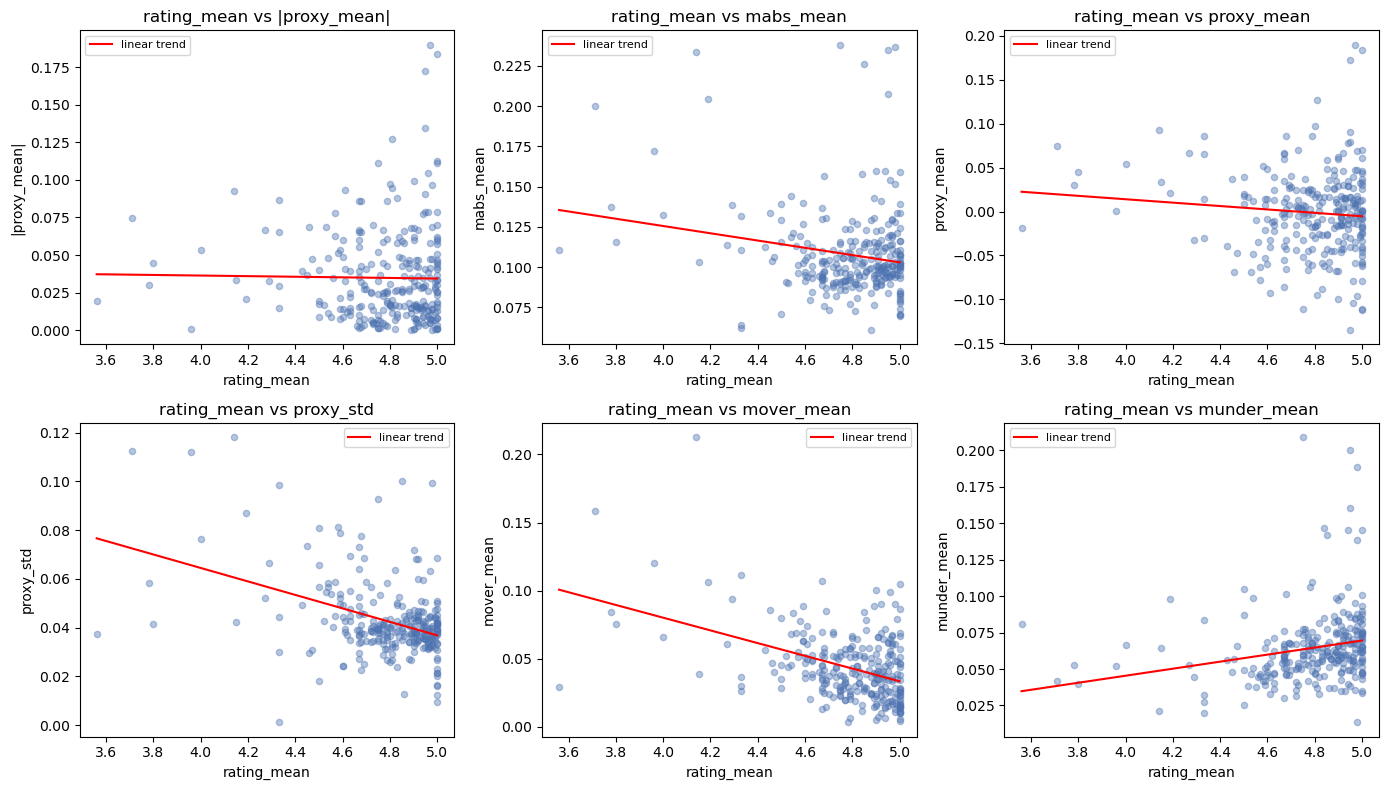

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
cols = ["abs_proxy_mean", "mabs_mean", "proxy_mean", "proxy_std", "mover_mean", "munder_mean"]
ylabels = ["|proxy_mean|", "mabs_mean", "proxy_mean", "proxy_std", "mover_mean", "munder_mean"]
for ax, col, ylabel in zip(axes.ravel(), cols, ylabels):
    ax.scatter(df["rating_mean"], df[col], alpha=0.4, s=20, color="#4C72B0")
    z = np.polyfit(df["rating_mean"], df[col], 1)
    x_plot = df["rating_mean"].sort_values()
    ax.plot(x_plot, np.poly1d(z)(x_plot), "r-", lw=1.5, label="linear trend")
    ax.set_xlabel("rating_mean")
    ax.set_ylabel(ylabel)
    ax.set_title(f"rating_mean vs {ylabel}")
    ax.legend(fontsize=8)
plt.tight_layout()

In [ ]:
# mover - munder 与 proxy 的散点图（listing 级别）
df["mover_munder"] = df["mover_mean"] - df["munder_mean"]
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ax.scatter(df["mover_munder"], df["proxy_mean"], alpha=0.4, s=25, color="#4C72B0")
z = np.polyfit(df["mover_munder"], df["proxy_mean"], 1)
x_plot = np.linspace(df["mover_munder"].min(), df["mover_munder"].max(), 100)
ax.plot(x_plot, np.poly1d(z)(x_plot), "r-", lw=1.5, label="linear trend")
r, p = stats.pearsonr(df["mover_munder"], df["proxy_mean"])
ax.set_xlabel("mover_mean - munder_mean")
ax.set_ylabel("proxy_mean")
ax.set_title(f"mover - munder vs proxy_mean (r={r:.3f}, p={p:.3e})")
ax.legend()
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.show()

**简要结论**：rating越高, 其 mismatch mignitude倾向于更小(mabs), 且更稳定（std小），说明desc和rev普遍更align, 且"oversells"更少，"undersells"更多

按 rating_mean 分三档（low < 4, mid [4, 4.5), high [4.5, 5]），比较 proxy_mean、mover_mean、munder_mean 的分布，并用 Kruskal-Wallis 检验三档差异。

In [46]:
# Bin rating_mean: low < 4, mid [4, 4.5), high [4.5, 5]
df["rating_bin"] = pd.cut(
    df["rating_mean"],
    bins=[0, 4.0, 4.5, 5.0],
    labels=["low (<4)", "mid [4,4.5)", "high [4.5,5]"],
    include_lowest=True,
)
print(df["rating_bin"].value_counts().sort_index())

rating_bin
low (<4)          6
mid [4,4.5)      17
high [4.5,5]    249
Name: count, dtype: int64


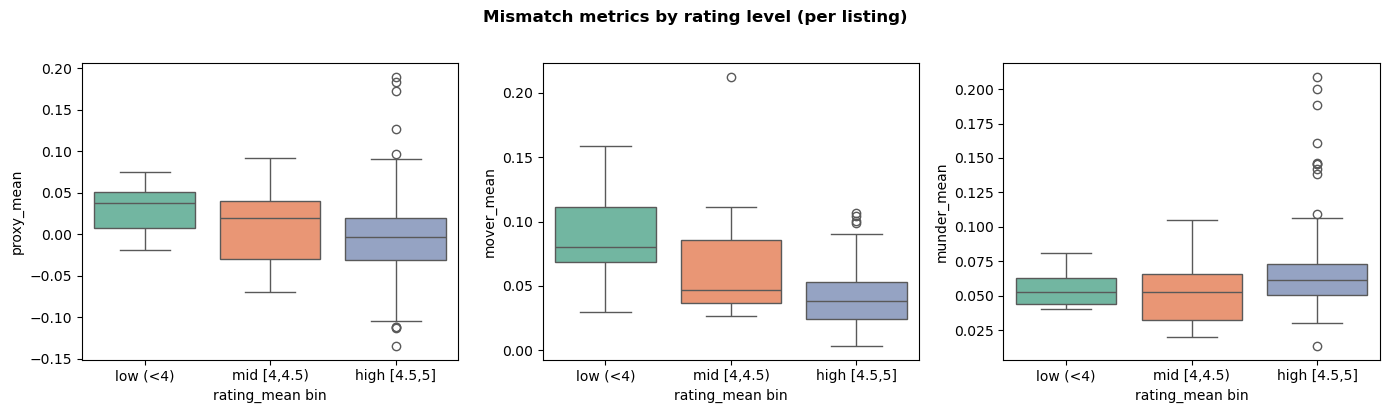

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["proxy_mean", "mover_mean", "munder_mean"]):
    sns.boxplot(data=df, x="rating_bin", y=col, hue="rating_bin", ax=ax, palette="Set2", legend=False)
    ax.set_xlabel("rating_mean bin")
    ax.set_ylabel(col)
plt.suptitle("Mismatch metrics by rating level (per listing)", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
#plt.savefig("rating_bin_mismatch.png", dpi=150, bbox_inches="tight")
#print("\nSaved: rating_bin_mismatch.png")

In [ ]:
# Kruskal-Wallis: test whether the three rating bins differ in proxy_mean, mover_mean, munder_mean
groups = [df.loc[df["rating_bin"] == b, "proxy_mean"].values for b in ["low (<4)", "mid [4,4.5)", "high [4.5,5]"]]
stat_proxy, p_proxy = stats.kruskal(*groups)
groups_mover = [df.loc[df["rating_bin"] == b, "mover_mean"].values for b in ["low (<4)", "mid [4,4.5)", "high [4.5,5]"]]
stat_mover, p_mover = stats.kruskal(*groups_mover)
groups_munder = [df.loc[df["rating_bin"] == b, "munder_mean"].values for b in ["low (<4)", "mid [4,4.5)", "high [4.5,5]"]]
stat_munder, p_munder = stats.kruskal(*groups_munder)
print("Kruskal-Wallis (across rating bins):")
print(f"  proxy_mean:  stat={stat_proxy:.4f}, p={p_proxy:.4e}")
print(f"  mover_mean:  stat={stat_mover:.4f}, p={p_mover:.4e}")
print(f"  munder_mean: stat={stat_munder:.4f}, p={p_munder:.4e}")
print("\n简要结论：若 p < 0.05，高/中/低评分 listing 在该指标上存在显著差异；否则差异不显著。")

Kruskal-Wallis (across rating bins):
  proxy_mean:  stat=7.4383, p=2.4255e-02
  mover_mean:  stat=14.9458, p=5.6829e-04
  munder_mean: stat=3.7906, p=1.5028e-01

简要结论：若 p < 0.05，高/中/低评分 listing 在该指标上存在显著差异；否则差异不显著。


## 3. 高评分且高 proxy_mean 的 listing

筛选 rating_mean >= 4.5 且 proxy_mean 高于 75% 分位数的 listing，可能对应「描述略夸大但整体体验仍好」的温和 over-description。

In [65]:
q75 = df["proxy_mean"].quantile(0.9)
high_rating_high_proxy = df[(df["rating_mean"] >= 4.9) & (df["proxy_mean"] >= q75)].copy()
high_rating_high_proxy = high_rating_high_proxy.sort_values("proxy_mean", ascending=False)


cols = ["listing_id","rating_mean", "proxy_mean", "review_count", "mabs_mean", "over_ratio"]
#print(f"Listing count (rating>=4.5 and proxy_mean >= 75% = {q75:.4f}): {len(high_rating_high_proxy)}")
#print(high_rating_high_proxy[cols].head(15).round(4).to_string())
high_rating_high_proxy[cols].round(4)

,listing_id,rating_mean,proxy_mean,review_count,mabs_mean,over_ratio
100,593272120497643087,4.97,0.1900,82,0.1142,1.0000
249,1393634936904017469,5.00,0.1835,4,0.0799,1.0000
35,30189794,4.95,0.1724,40,0.2078,1.0000
124,756752556396798800,4.95,0.0905,10,0.0836,1.0000
64,47440071,4.95,0.0786,137,0.1184,0.9854
109,668608486588067880,4.94,0.0775,74,0.1600,1.0000
136,803682039097862541,5.00,0.0698,22,0.0979,0.9545
144,850173470105833039,4.98,0.0689,158,0.1033,0.9873
14,17238066,4.92,0.0667,51,0.0995,0.9216
28,25549565,4.90,0.0622,498,0.1227,0.9398


In [13]:
# 从 df_llm 中选出 mismatch_proxy 最高 5% 和最低 5% 的数据
p95 = df_llm["mismatch_proxy"].quantile(0.95)
p05 = df_llm["mismatch_proxy"].quantile(0.05)
top5 = df_llm[df_llm["mismatch_proxy"] >= p95].sort_values("mismatch_proxy", ascending=False)
bottom5 = df_llm[df_llm["mismatch_proxy"] <= p05].sort_values("mismatch_proxy", ascending=True)
print(f"mismatch_proxy 最高 5%: 阈值 >= {p95:.4f}, 行数 = {len(top5)}")
print(f"mismatch_proxy 最低 5%: 阈值 <= {p05:.4f}, 行数 = {len(bottom5)}")

mismatch_proxy 最高 5%: 阈值 >= 0.0953, 行数 = 698
mismatch_proxy 最低 5%: 阈值 <= -0.0913, 行数 = 698


In [15]:
# 两组（top5 vs bottom5）在 rating, proxy_std, mabs, mover, munder 上的比较
# proxy_std 为 listing 级别，需从 df (listing_mismatch_summary) 合并
df_listing_std = df[["listing_id", "proxy_std"]].drop_duplicates()
top5_m = top5.merge(df_listing_std, on="listing_id", how="left")
bottom5_m = bottom5.merge(df_listing_std, on="listing_id", how="left")

metrics = ["rating", "proxy_std", "mabs", "mover", "munder"]
summary = []
for col in metrics:
    t = top5_m[col].dropna()
    b = bottom5_m[col].dropna()
    stat, p = stats.mannwhitneyu(t, b, alternative="two-sided")
    summary.append({
        "metric": col,
        "top5_mean": t.mean(),
        "top5_std": t.std(),
        "top5_median": t.median(),
        "bottom5_mean": b.mean(),
        "bottom5_std": b.std(),
        "bottom5_median": b.median(),
        "MannWhitney_U": stat,
        "p_value": p,
    })
summary_df = pd.DataFrame(summary)
print("Top5 vs Bottom5 描述统计与 Mann-Whitney U 检验:\n")
print(summary_df.round(4).to_string(index=False))

Top5 vs Bottom5 描述统计与 Mann-Whitney U 检验:

   metric  top5_mean  top5_std  top5_median  bottom5_mean  bottom5_std  bottom5_median  MannWhitney_U  p_value
   rating     4.8419    0.2061       4.9000        4.8063       0.1393          4.8300       302693.0   0.0000
proxy_std     0.0415    0.0100       0.0406        0.0441       0.0123          0.0403       211390.0   0.0005
     mabs     0.1452    0.1018       0.1162        0.1378       0.0410          0.1308       203682.0   0.0000
    mover     0.0956    0.1140       0.0575        0.0340       0.0279          0.0282       344148.0   0.0000
   munder     0.0496    0.0448       0.0419        0.1038       0.0453          0.0968        83270.0   0.0000


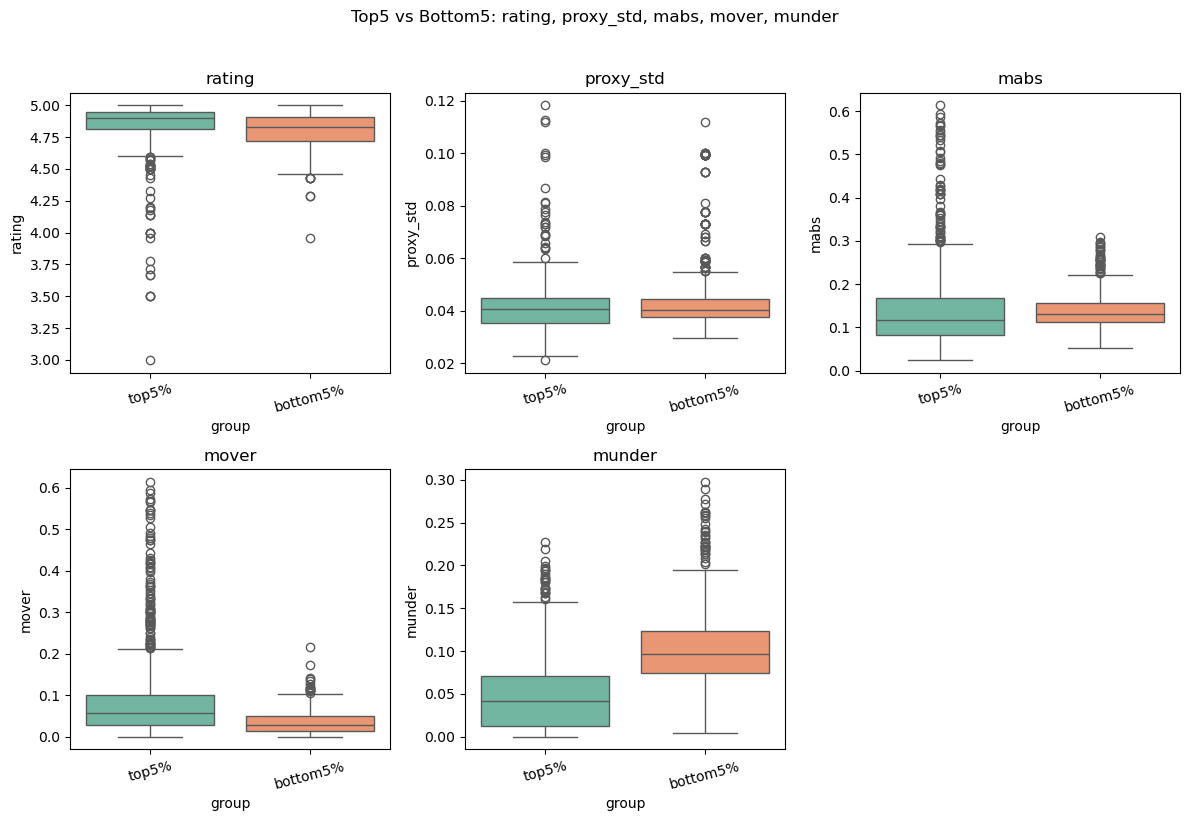

In [26]:
# 箱线图对比
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.ravel()
for ax, col in zip(axes, metrics):
    plot_df = pd.DataFrame({
        "value": list(top5_m[col].dropna()) + list(bottom5_m[col].dropna()),
        "group": ["top5%"] * top5_m[col].notna().sum() + ["bottom5%"] * bottom5_m[col].notna().sum(),
    })
    sns.boxplot(data=plot_df, x="group", y="value", hue="group", ax=ax, palette="Set2", legend=False)
    ax.set_ylabel(col)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=15)
axes[-1].axis("off")
plt.suptitle("Top5 vs Bottom5: rating, proxy_std, mabs, mover, munder", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

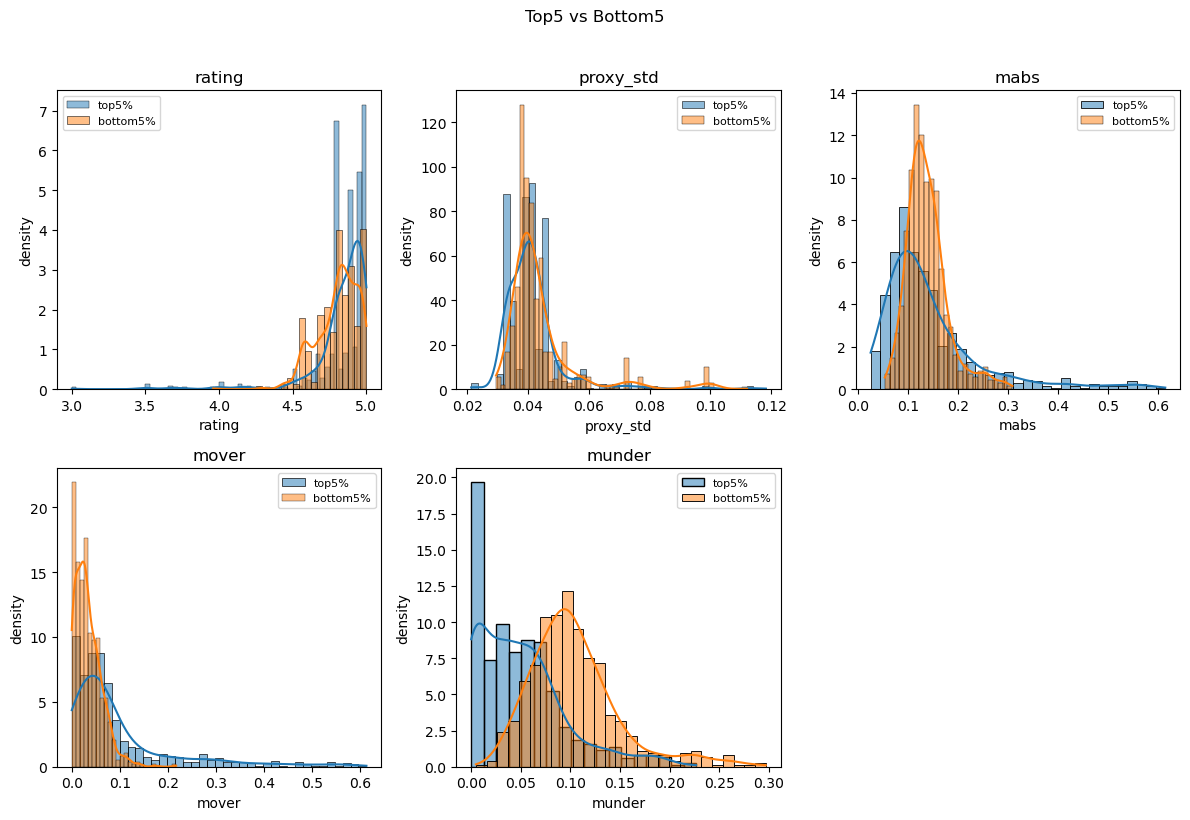

In [24]:
# 直方分布图对比（同一子图内 top5 与 bottom5 叠加）
fig2, axes2 = plt.subplots(2, 3, figsize=(12, 8))
axes2 = axes2.ravel()
for ax, col in zip(axes2, metrics):
    sns.histplot(top5_m[col].dropna(), ax=ax, label="top5%", kde=True, color="C0", alpha=0.5, stat="density")
    sns.histplot(bottom5_m[col].dropna(), ax=ax, label="bottom5%", kde=True, color="C1", alpha=0.5, stat="density")
    ax.set_xlabel(col)
    ax.set_ylabel("density")
    ax.set_title(col)
    ax.legend(fontsize=8)
axes2[-1].axis("off")
plt.suptitle("Top5 vs Bottom5", fontsize=12, y=1.02)
plt.tight_layout()

top proxy的分布倾向更长尾。top proxy仍然有很多高rating, bottom proxy rating在4.5-5区间内分布相对更均匀。top proxy的mover更长尾，bottom oversell的现象明显少，munder则相反。

In [30]:
# 两组（top5 vs bottom5）在各维度 delta_S01..delta_S10 上的分布比较
dim_cols = [f"delta_S{i:02d}" for i in range(1, 11)]

# 描述统计 + Mann-Whitney U 检验
dim_summary = []
for col in dim_cols:
    t = top5_m[col].dropna()
    b = bottom5_m[col].dropna()
    stat, p = stats.mannwhitneyu(t, b, alternative="two-sided")
    dim_summary.append({
        "dim": col,
        "top5_mean": t.mean(),
        "top5_std": t.std(),
        "bottom5_mean": b.mean(),
        "bottom5_std": b.std(),
        "MannWhitney_p": p,
    })
dim_summary_df = pd.DataFrame(dim_summary)
print("Top5 vs Bottom5 各维度 (delta_S0x) 描述统计与 Mann-Whitney U 检验:\n")
print(dim_summary_df.round(4).to_string(index=False))

Top5 vs Bottom5 各维度 (delta_S0x) 描述统计与 Mann-Whitney U 检验:

      dim  top5_mean  top5_std  bottom5_mean  bottom5_std  MannWhitney_p
delta_S01     0.0850    0.1818       -0.2077       0.1475            0.0
delta_S02     0.0209    0.2485        0.0292       0.1199            0.0
delta_S03     0.0594    0.1622       -0.2421       0.1200            0.0
delta_S04     0.0080    0.2366        0.0954       0.1141            0.0
delta_S05     0.0134    0.1497       -0.0276       0.0775            0.0
delta_S06    -0.0150    0.1990        0.0392       0.1202            0.0
delta_S07     0.0898    0.2015       -0.0449       0.1558            0.0
delta_S08     0.0355    0.1759       -0.1487       0.1366            0.0
delta_S09     0.1365    0.1520       -0.1454       0.1055            0.0
delta_S10     0.0259    0.1819       -0.0448       0.1205            0.0


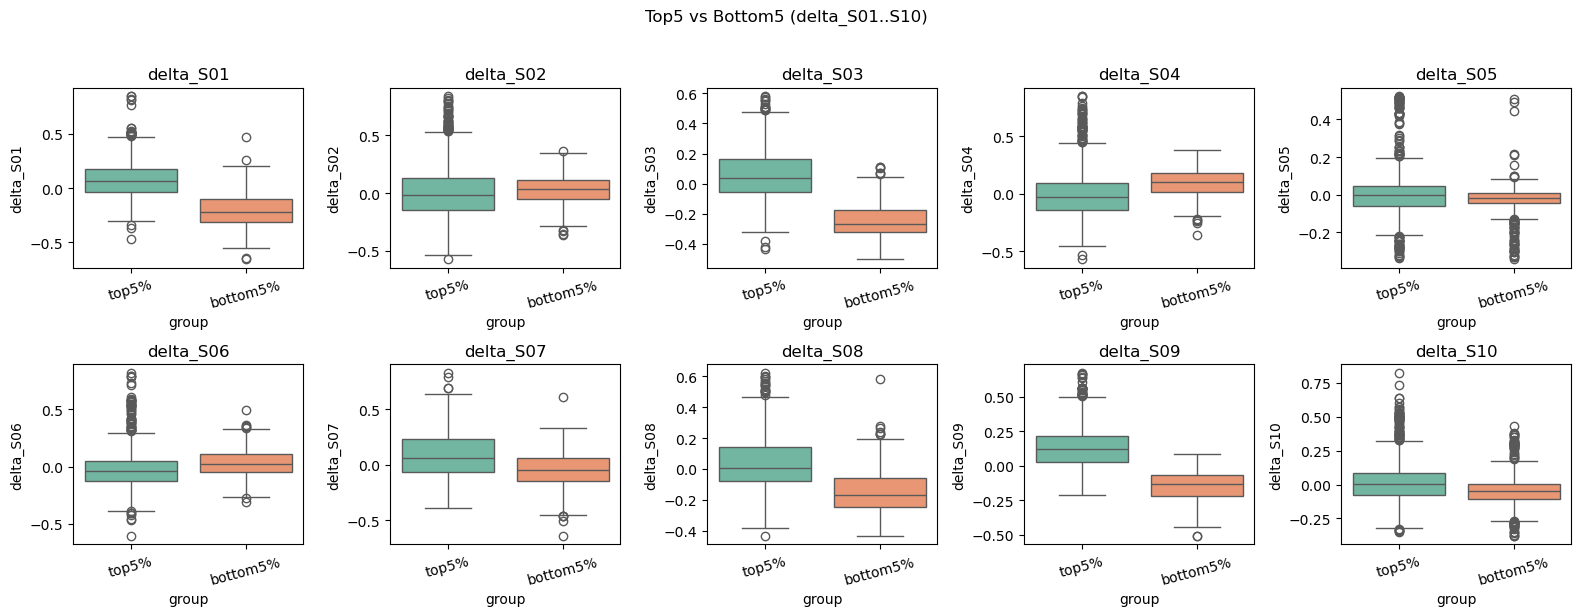

In [32]:
# 各维度分布对比：箱线图 (2x5)
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
axes = axes.ravel()
for ax, col in zip(axes, dim_cols):
    plot_df = pd.DataFrame({
        "value": list(top5_m[col].dropna()) + list(bottom5_m[col].dropna()),
        "group": ["top5%"] * top5_m[col].notna().sum() + ["bottom5%"] * bottom5_m[col].notna().sum(),
    })
    sns.boxplot(data=plot_df, x="group", y="value", hue="group", ax=ax, palette="Set2", legend=False)
    ax.set_ylabel(col)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=15)
plt.suptitle("Top5 vs Bottom5 (delta_S01..S10)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


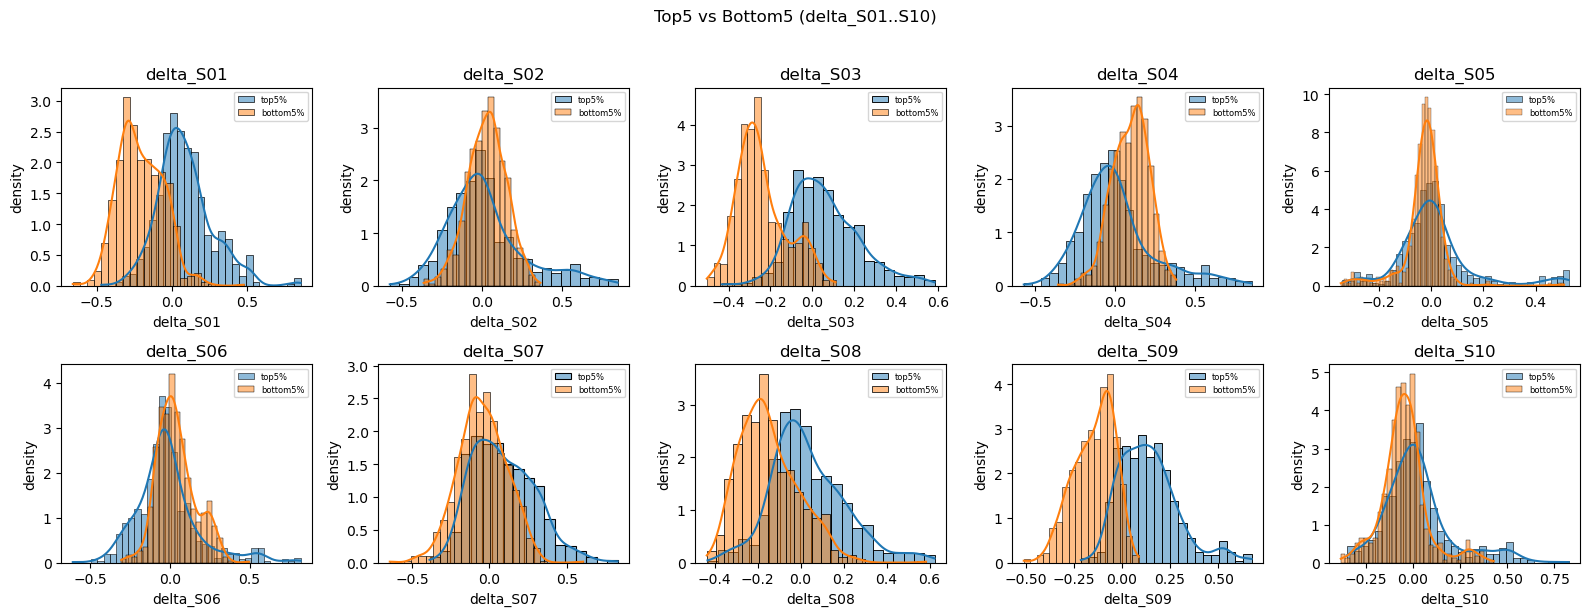

In [ ]:
# 各维度分布对比：直方图 (2x5，同一子图内 top5 与 bottom5 叠加)
fig2, axes2 = plt.subplots(2, 5, figsize=(16, 6))
axes2 = axes2.ravel()
for ax, col in zip(axes2, dim_cols):
    sns.histplot(top5_m[col].dropna(), ax=ax, label="top5%", kde=True, color="C0", alpha=0.5, stat="density")
    sns.histplot(bottom5_m[col].dropna(), ax=ax, label="bottom5%", kde=True, color="C1", alpha=0.5, stat="density")
    ax.set_xlabel(col)
    ax.set_ylabel("density")
    ax.set_title(col)
    ax.legend(fontsize=6)
plt.suptitle("Top5 vs Bottom5 (delta_S01..S10)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


top delta倾向于更高，尤其是clean bed, friendly host, private bedroom, reponsive host, cozy apartment的desc分数高于rev. 与location相关的维度（location perfect, central location, near shops）top反而倾向有更小的delta.

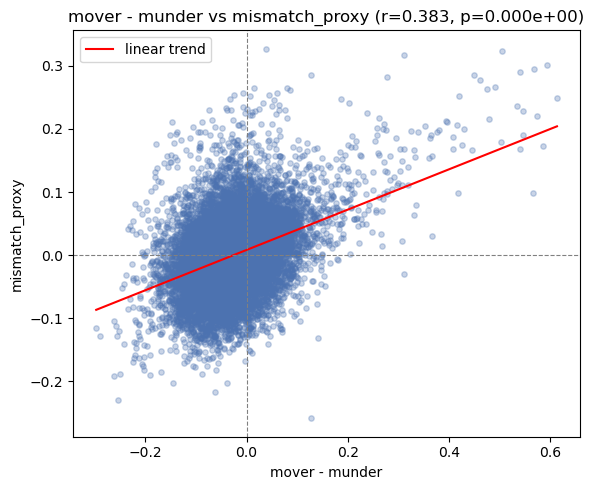

In [41]:
# mover - munder 与 proxy 的散点图（df_llm 全部数据）
df_llm["mover_munder"] = df_llm["mover"] - df_llm["munder"]
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ax.scatter(df_llm["mover_munder"], df_llm["mismatch_proxy"], alpha=0.3, s=15, color="#4C72B0")
z = np.polyfit(df_llm["mover_munder"], df_llm["mismatch_proxy"], 1)
x_plot = np.linspace(df_llm["mover_munder"].min(), df_llm["mover_munder"].max(), 500)
ax.plot(x_plot, np.poly1d(z)(x_plot), "r-", lw=1.5, label="linear trend")
r, p = stats.pearsonr(df_llm["mover_munder"], df_llm["mismatch_proxy"])
ax.set_xlabel("mover - munder")
ax.set_ylabel("mismatch_proxy")
ax.set_title(f"mover - munder vs mismatch_proxy (r={r:.3f}, p={p:.3e})")
ax.legend()
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.show()

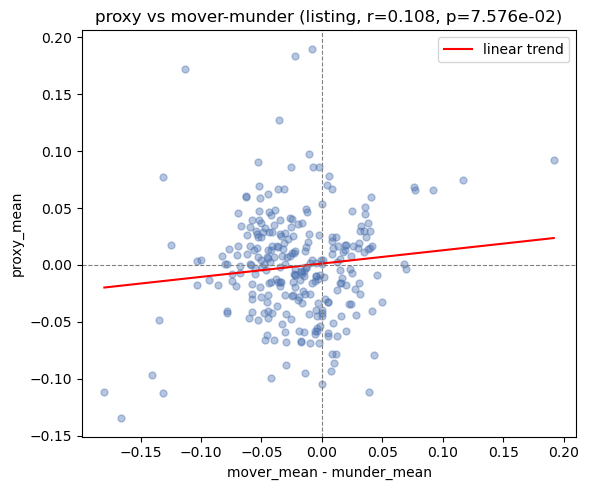

In [42]:
# df（listing 级别）上 proxy 与 mover - munder 的关系
df["mover_munder"] = df["mover_mean"] - df["munder_mean"]
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ax.scatter(df["mover_munder"], df["proxy_mean"], alpha=0.4, s=25, color="#4C72B0")
z = np.polyfit(df["mover_munder"], df["proxy_mean"], 1)
x_plot = np.linspace(df["mover_munder"].min(), df["mover_munder"].max(), 100)
ax.plot(x_plot, np.poly1d(z)(x_plot), "r-", lw=1.5, label="linear trend")
r, p = stats.pearsonr(df["mover_munder"], df["proxy_mean"])
ax.set_xlabel("mover_mean - munder_mean")
ax.set_ylabel("proxy_mean")
ax.set_title(f"proxy vs mover-munder (listing, r={r:.3f}, p={p:.3e})")
ax.legend()
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.show()

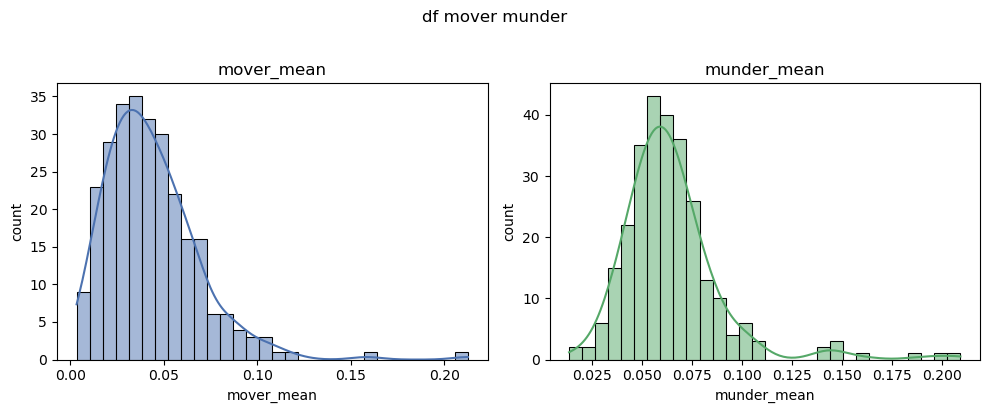

In [46]:
# df 中 mover_mean 与 munder_mean 的直方图
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(df["mover_mean"], kde=True, ax=axes[0], color="#4C72B0", bins=30)
axes[0].set_xlabel("mover_mean")
axes[0].set_ylabel("count")
axes[0].set_title("mover_mean")
sns.histplot(df["munder_mean"], kde=True, ax=axes[1], color="#55A868", bins=30)
axes[1].set_xlabel("munder_mean")
axes[1].set_ylabel("count")
axes[1].set_title("munder_mean")
plt.suptitle("df mover munder", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

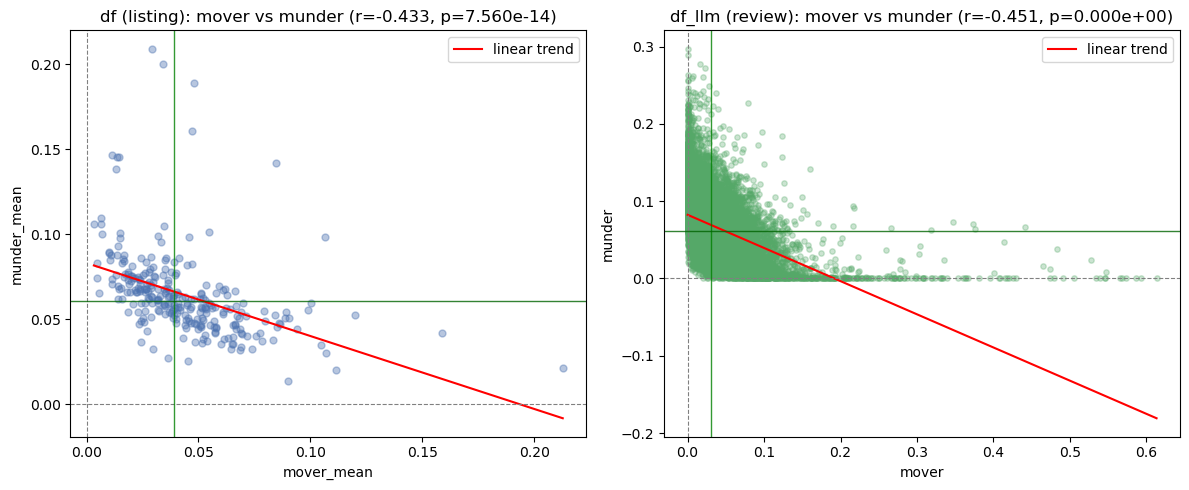

In [45]:
# mover 与 munder 的散点图：df（listing）与 df_llm（review）分别做
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# df: mover_mean vs munder_mean
ax = axes[0]
ax.scatter(df["mover_mean"], df["munder_mean"], alpha=0.4, s=25, color="#4C72B0")
z = np.polyfit(df["mover_mean"], df["munder_mean"], 1)
x_plot = np.linspace(df["mover_mean"].min(), df["mover_mean"].max(), 100)
ax.plot(x_plot, np.poly1d(z)(x_plot), "r-", lw=1.5, label="linear trend")
r, p = stats.pearsonr(df["mover_mean"], df["munder_mean"])
ax.set_xlabel("mover_mean")
ax.set_ylabel("munder_mean")
ax.set_title(f"df (listing): mover vs munder (r={r:.3f}, p={p:.3e})")
ax.legend()
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)
med_mover, med_munder = df["mover_mean"].median(), df["munder_mean"].median()
ax.axvline(med_mover, color="green", linestyle="-", linewidth=1, alpha=0.8, label=f"median mover={med_mover:.3f}")
ax.axhline(med_munder, color="darkgreen", linestyle="-", linewidth=1, alpha=0.8, label=f"median munder={med_munder:.3f}")

# df_llm: mover vs munder
ax = axes[1]
ax.scatter(df_llm["mover"], df_llm["munder"], alpha=0.3, s=15, color="#55A868")
z = np.polyfit(df_llm["mover"], df_llm["munder"], 1)
x_plot = np.linspace(df_llm["mover"].min(), df_llm["mover"].max(), 100)
ax.plot(x_plot, np.poly1d(z)(x_plot), "r-", lw=1.5, label="linear trend")
r, p = stats.pearsonr(df_llm["mover"], df_llm["munder"])
ax.set_xlabel("mover")
ax.set_ylabel("munder")
ax.set_title(f"df_llm (review): mover vs munder (r={r:.3f}, p={p:.3e})")
ax.legend()
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)
med_mover, med_munder = df_llm["mover"].median(), df_llm["munder"].median()
ax.axvline(med_mover, color="green", linestyle="-", linewidth=1, alpha=0.8, label=f"median mover={med_mover:.3f}")
ax.axhline(med_munder, color="darkgreen", linestyle="-", linewidth=1, alpha=0.8, label=f"median munder={med_munder:.3f}")

plt.tight_layout()
plt.show()

In [47]:
# 在 top5（mismatch_proxy 最高 5%）中选出 rating 最高和 rating 最低的一部分数据
n_sub = 50  # 各取 50 条，可按需修改；也可用分位数
top5_high_rating = top5.nlargest(n_sub, "rating").sort_values("rating", ascending=False)
top5_low_rating = top5.nsmallest(n_sub, "rating").sort_values("rating", ascending=True)
print(f"top5 中 rating 最高的 {n_sub} 条: 行数 = {len(top5_high_rating)}, rating 范围 = {top5_high_rating['rating'].min():.2f} ~ {top5_high_rating['rating'].max():.2f}")
print(f"top5 中 rating 最低的 {n_sub} 条: 行数 = {len(top5_low_rating)}, rating 范围 = {top5_low_rating['rating'].min():.2f} ~ {top5_low_rating['rating'].max():.2f}")

top5 中 rating 最高的 50 条: 行数 = 50, rating 范围 = 4.98 ~ 5.00
top5 中 rating 最低的 50 条: 行数 = 50, rating 范围 = 3.00 ~ 4.63


In [ ]:
print("\n--- top5 中 rating 最高 10 条示例 ---")
print(top5_high_rating[["listing_id", "review_id", "rating", "mismatch_proxy", "mover", "munder"]].head(10).to_string())
print("\n--- top5 中 rating 最低 10 条示例 ---")
print(top5_low_rating[["listing_id", "review_id", "rating", "mismatch_proxy", "mover", "munder"]].head(10).to_string())

In [54]:
# mover_munder 与 rating_mean 的 Spearman 和 Pearson 相关系数
df["mover_munder"] = df["mover_mean"] - df["munder_mean"]
rho_s, p_s = stats.spearmanr(df["mover_munder"], df["rating_mean"], nan_policy="omit")
r_p, p_p = stats.pearsonr(df["mover_munder"], df["rating_mean"])
print("mover_munder vs rating_mean (df):")
print(f"  Spearman: rho = {rho_s:.4f}, p = {p_s:.4e}")
print(f"  Pearson:  r   = {r_p:.4f}, p = {p_p:.4e}")

mover_munder vs rating_mean (df):
  Spearman: rho = -0.3447, p = 5.2577e-09
  Pearson:  r   = -0.3781, p = 1.1301e-10


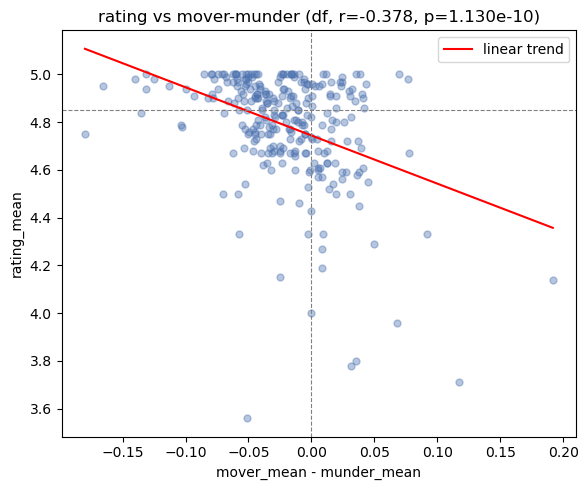

In [53]:
df["mover_munder"] = df["mover_mean"] - df["munder_mean"]
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ax.scatter(df["mover_munder"], df["rating_mean"], alpha=0.4, s=25, color="#4C72B0")
z = np.polyfit(df["mover_munder"], df["rating_mean"], 1)
x_plot = np.linspace(df["mover_munder"].min(), df["mover_munder"].max(), 100)
ax.plot(x_plot, np.poly1d(z)(x_plot), "r-", lw=1.5, label="linear trend")
r, p = stats.pearsonr(df["mover_munder"], df["rating_mean"])
ax.set_xlabel("mover_mean - munder_mean")
ax.set_ylabel("rating_mean")
ax.set_title(f"rating vs mover-munder (df, r={r:.3f}, p={p:.3e})")
ax.legend()
ax.axhline(df["rating_mean"].median(), color="gray", linestyle="--", linewidth=0.8)
ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)
plt.tight_layout()

In [55]:
# review_count 与 mover_munder 的相关关系（Spearman / Pearson）及散点图
df["mover_munder"] = df["mover_mean"] - df["munder_mean"]
rho_s, p_s = stats.spearmanr(df["review_count"], df["mover_munder"], nan_policy="omit")
r_p, p_p = stats.pearsonr(df["review_count"], df["mover_munder"])
print("review_count vs mover_munder (df):")
print(f"  Spearman: rho = {rho_s:.4f}, p = {p_s:.4e}")
print(f"  Pearson:  r   = {r_p:.4f}, p = {p_p:.4e}")

review_count vs mover_munder (df):
  Spearman: rho = -0.0881, p = 1.4733e-01
  Pearson:  r   = -0.0873, p = 1.5124e-01


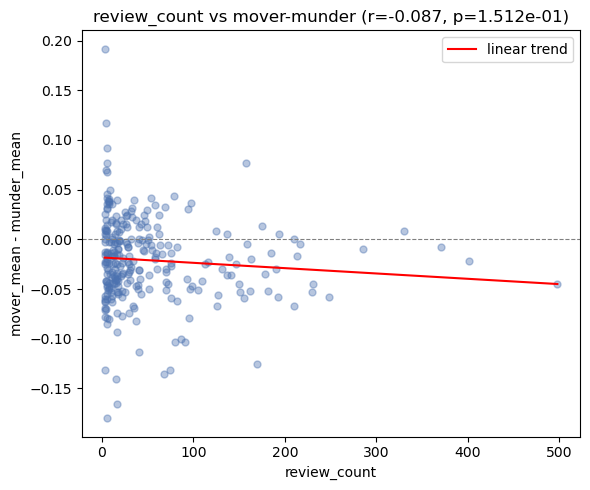

In [56]:

fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ax.scatter(df["review_count"], df["mover_munder"], alpha=0.4, s=25, color="#4C72B0")
z = np.polyfit(df["review_count"], df["mover_munder"], 1)
x_plot = np.linspace(df["review_count"].min(), df["review_count"].max(), 100)
ax.plot(x_plot, np.poly1d(z)(x_plot), "r-", lw=1.5, label="linear trend")
ax.set_xlabel("review_count")
ax.set_ylabel("mover_mean - munder_mean")
ax.set_title(f"review_count vs mover-munder (r={r_p:.3f}, p={p_p:.3e})")
ax.legend()
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.show()

In [57]:
# 从 df_llm 中选出 mismatch_proxy 最高 5% 和最低 5% 的数据
p95 = df_llm["mabs"].quantile(0.95)
p05 = df_llm["mabs"].quantile(0.05)
top5 = df_llm[df_llm["mabs"] >= p95].sort_values("mabs", ascending=False)
bottom5 = df_llm[df_llm["mabs"] <= p05].sort_values("mabs", ascending=True)
print(f"mismatch_proxy 最高 5%: 阈值 >= {p95:.4f}, 行数 = {len(top5)}")
print(f"mismatch_proxy 最低 5%: 阈值 <= {p05:.4f}, 行数 = {len(bottom5)}")

mismatch_proxy 最高 5%: 阈值 >= 0.1708, 行数 = 698
mismatch_proxy 最低 5%: 阈值 <= 0.0513, 行数 = 698
